# Pairs trading on the day lake — II. Does cointegration exist?

## `pairs_trading_08_daily_cointegration.ipynb`

Notebook 07 built a point-in-time universe from the day lake and fixed the price basis. This notebook
asks the question the whole strategy rests on and that notebooks 01–05 never tested at scale: **among
liquid US equities, are there actually cointegrated pairs — more than a multiple-testing artifact would
produce?**

The design is a standing screen: at each of 39 semi-annual formation dates from 2006 to 2025, take the
300 most traded eligible names, test every pair of them — up to 44,850 — with the Engle–Granger and
Johansen dual gate, and
keep the whole p-value distribution rather than only the winners. Twenty years and 1.7 million tests are
enough to answer the question with the null hypothesis stated properly.

Three things come out of it: the pooled p-value distribution against the uniform null, the
Benjamini–Hochberg discoveries era by era, and the identity of what actually passes. Notebook 09 then
trades the result.

**Caching.** The screen is about 35 minutes cold on 16 cores and is cached as
`cache/day_screen.parquet`; everything after it is instant.

## 0. Setup and the point-in-time universe

In [1]:
from pathlib import Path
import os, sys, time, re, warnings, itertools

repo_root = Path.cwd().parent
sys.path.insert(0, str(repo_root))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pairs
from pairs import (load_universe, load_daily_bars, liquidity_screen,
                   find_cointegrated_pairs_dualgate, benjamini_hochberg_fdr)

LAKE        = Path(os.environ.get("DAY_LAKE", Path.home() / "local/parquet_lake/day_adj"))
MARKET_ROOT = LAKE / "all_adjusted"
CACHE = Path("cache"); CACHE.mkdir(exist_ok=True)

START, END = "2004-01-01", "2025-08-13"
FORM_YEARS, MIN_PRICE, MIN_DV, MIN_VOL, TOP_N = 2, 5.0, 20e6, 0.15, 300
MAX_ABS_RET, ALPHA = 1.0, 0.05
plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 100})

f_bars = CACHE / "day_market_bars.parquet"
if f_bars.exists():
    bars = pd.read_parquet(f_bars)
else:
    bars = load_daily_bars(None, START, END, MARKET_ROOT, with_dividends=True)
    bars.to_parquet(f_bars)
sessions = pd.DatetimeIndex(sorted(bars.index.get_level_values("datetime").unique()))

def formation_dates(first="2006-06-30", freq="6MS"):
    anchors = pd.date_range(first, sessions[-1], freq=freq)
    return pd.DatetimeIndex(sorted({sessions[sessions <= a][-1] for a in anchors if (sessions <= a).any()}))

def window_bars(end, years=FORM_YEARS):
    start = end - pd.DateOffset(years=years)
    lvl = bars.index.get_level_values("datetime")
    return bars[(lvl > start) & (lvl <= end)]

TEST_SYMBOLS = sorted(t for t in bars.index.get_level_values("ticker").unique()
                      if re.fullmatch(r"Z[A-Z]ZZT", str(t)))     # NASDAQ test symbols; see notebook 07

def universe_at(end, years=FORM_YEARS, top_n=TOP_N):
    st = liquidity_screen(window_bars(end, years), min_price=MIN_PRICE, min_dollar_volume=MIN_DV,
                          min_ann_vol=MIN_VOL, max_abs_return=MAX_ABS_RET, exclude=TEST_SYMBOLS,
                          top_n=top_n)
    return list(st[st["eligible"]].index)

FORMATIONS = formation_dates()
print("pairs", pairs.__version__, f"| {len(FORMATIONS)} formations {FORMATIONS[0].date()} → {FORMATIONS[-1].date()}"
      f" | {len(bars):,} bar-rows over {len(sessions):,} sessions")
print(f"universe rules: {FORM_YEARS}y window, raw close ≥ ${MIN_PRICE:.0f}, ≥ ${MIN_DV/1e6:.0f}M/day, "
      f"ann vol ≥ {MIN_VOL:.0%}, max |1-day return| ≤ {MAX_ABS_RET:.0%}, {len(TEST_SYMBOLS)} test symbols excluded; "
      f"top {TOP_N} by dollar volume")

pairs 0.1.0 | 39 formations 2006-06-30 → 2025-07-01 | 43,764,473 bar-rows over 5,438 sessions
universe rules: 2y window, raw close ≥ $5, ≥ $20M/day, ann vol ≥ 15%, max |1-day return| ≤ 100%, 13 test symbols excluded; top 300 by dollar volume


## 1. The screen

At each formation date the trailing two years of split-adjusted closes for the 300 most traded eligible
names go through `find_cointegrated_pairs_dualgate`: Engle–Granger on every ordered pair with
Benjamini–Hochberg correction, and the Johansen trace test as a second gate. Every p-value is kept, not
just the passing ones — the distribution is the evidence.

The universe rules are notebook 07's, including the three that a curated index list would have hidden:
the price gate reads the **unadjusted** close, one-day moves above 100% mark an unadjusted corporate
action and disqualify the name for that window, and exchange test symbols are dropped by name.

In [2]:
def screen_one(end):
    names = universe_at(end)
    w = window_bars(end)
    px = w["close"].unstack("ticker")[names].dropna(axis=1)
    long = px.stack().rename("close").to_frame()
    long.index.names = ["datetime", "ticker"]
    long = long.reorder_levels(["ticker", "datetime"]).sort_index()
    sc = find_cointegrated_pairs_dualgate(long, alpha_eg=ALPHA, alpha_joh=ALPHA, fdr_method="bh",
                                          show_progress=False)
    sc = sc.reset_index()
    sc.insert(0, "formation", end)
    return sc

f_screen = CACHE / "day_screen.parquet"
if f_screen.exists():
    screen = pd.read_parquet(f_screen)
else:
    t0 = time.time(); out = []
    for i, d in enumerate(FORMATIONS, 1):
        out.append(screen_one(d))
        print(f"  {i:>2}/{len(FORMATIONS)} {d.date()}: {len(out[-1]):,} pairs, "
              f"{int(out[-1]['verdict'].eq('pass').sum())} pass  [{time.time() - t0:.0f}s]", flush=True)
    screen = pd.concat(out, ignore_index=True)
    screen.to_parquet(f_screen)
print(f"{len(screen):,} pair-tests over {screen['formation'].nunique()} formations")
per_form = screen.groupby("formation").agg(pairs=("eg_p", "size"), bh_dual=("verdict", lambda v: int((v == "pass").sum())),
                                           raw_eg=("eg_p", lambda p: int((p <= ALPHA).sum())),
                                           johansen=("joh_pass", "sum"))
per_form["raw_dual"] = screen.groupby("formation").apply(lambda g: int(((g["eg_p"] <= ALPHA) & g["joh_pass"]).sum()))
per_form["raw_eg_rate"] = per_form["raw_eg"] / per_form["pairs"]
display(per_form.head(8).round(4))

1,738,998 pair-tests over 39 formations


,pairs,bh_dual,raw_eg,johansen,raw_dual,raw_eg_rate
formation,,,,,,
2006-06-30,43956,34,3912,5784,2629,0.0890
2006-12-29,44253,0,1992,4888,1299,0.0450
2007-06-29,44253,0,2374,4404,1302,0.0536
2007-12-31,44253,0,2236,4784,1422,0.0505
2008-07-01,44551,3,2202,4933,1416,0.0494
2008-12-31,44551,5,1738,3652,1038,0.0390
2009-07-01,44551,5,2905,5465,1958,0.0652
2009-12-31,44850,12,4061,10918,3210,0.0905


## 2. The p-values against the null

If no pair in the universe were cointegrated, the Engle–Granger p-values would be uniform on $[0,1]$ and
the test would reject at exactly $\alpha$. That is the benchmark to beat, and it is the comparison the
"we found 2,000 cointegrated pairs" style of result never makes.

Two readings of the same data:

* the **pooled histogram** of all 1.7 million p-values against the uniform density; genuine cointegration
  shows up as a spike near zero on top of a flat background;
* **Storey's $\hat\pi_0$**, the estimated fraction of true nulls, taken as
  $\hat\pi_0(\lambda) = \#\{p > \lambda\} / (m(1-\lambda))$. A value at or above 1 means the data are
  consistent with *nothing* being cointegrated.

One caveat on the pooling: the 39 formation windows are two years long and step six months, so they
overlap and the tests are not independent across formations. Benjamini–Hochberg remains valid under this
kind of positive dependence, and the per-formation rejection rates in §3 tell the same story one window
at a time, so the pooled picture is not an artifact of the overlap.

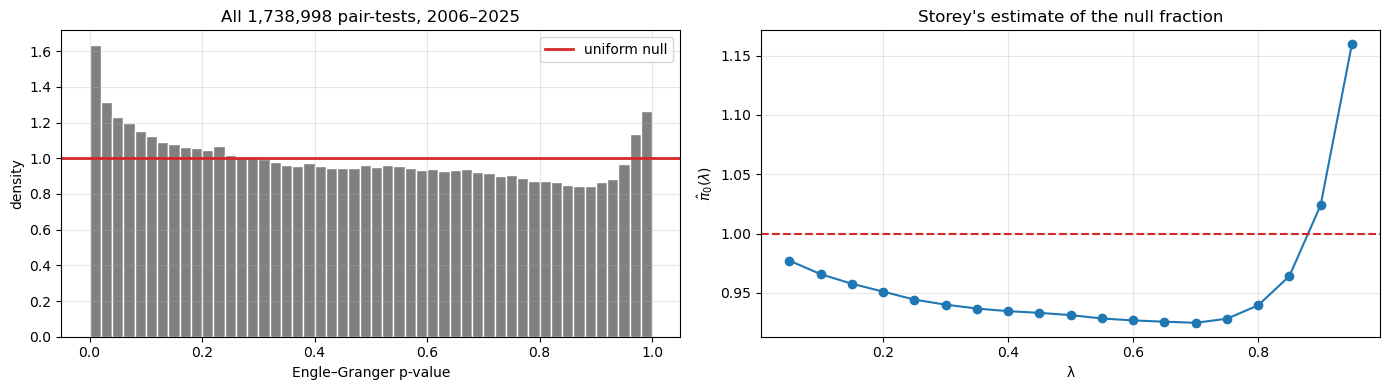

share of p-values below 0.05: 7.158%  (uniform null predicts 5.0%)
Storey pi0 at lambda=0.5: 0.931
excess below 0.05 over the null: +2.158% of tests, i.e. about 37,536 pairs across twenty years


In [3]:
p = screen["eg_p"].to_numpy()
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].hist(p, bins=50, density=True, color="0.5", edgecolor="white")
ax[0].axhline(1.0, color="tab:red", lw=2, label="uniform null")
ax[0].set_xlabel("Engle–Granger p-value"); ax[0].set_ylabel("density")
ax[0].set_title(f"All {len(p):,} pair-tests, 2006–2025"); ax[0].legend()
lam = np.arange(0.05, 0.96, 0.05)
pi0 = [(p > l).sum() / (len(p) * (1 - l)) for l in lam]
ax[1].plot(lam, pi0, marker="o", lw=1.5)
ax[1].axhline(1.0, color="tab:red", lw=1.5, ls="--")
ax[1].set_xlabel("λ"); ax[1].set_ylabel(r"$\hat\pi_0(\lambda)$"); ax[1].set_title("Storey's estimate of the null fraction")
plt.tight_layout(); plt.show()
print(f"share of p-values below {ALPHA}: {(p <= ALPHA).mean():.3%}  (uniform null predicts {ALPHA:.1%})")
print(f"Storey pi0 at lambda=0.5: {(p > 0.5).sum() / (len(p) * 0.5):.3f}")
print(f"excess below {ALPHA} over the null: {(p <= ALPHA).mean() - ALPHA:+.3%} of tests, "
      f"i.e. about {int(((p <= ALPHA).mean() - ALPHA) * len(p)):,} pairs across twenty years")

There is a real excess, and it is small. Against a uniform null predicting 5.0%, **7.16%** of the 1.74
million tests reject at the 5% level, and Storey's estimator puts the fraction of true nulls at
$\hat\pi_0 = 0.93$. So roughly 7% of pairs carry *something* — about 37,500 pair-tests' worth of excess
across twenty years — and the other 93% are indistinguishable from noise.

That is the honest shape of the evidence. It rules out the strong claim, common in the applied literature
and implicit in notebooks 01–05, that liquid equity pairs are richly cointegrated: if they were, the
histogram would show a large spike at zero rather than a flat bar at 1.0 with a modest lip. It also rules
out the nihilist reading that there is nothing there at all. The question is whether the excess is
concentrated in pairs strong enough to be identified individually — which is what FDR control answers
next.

Two details of the figure are worth naming rather than glossing. The histogram is also raised at the
*right* end, near $p = 1$: the augmented Dickey–Fuller statistic is conservative in finite samples on
strongly correlated series, so the test under-rejects more often than a textbook null would. That is why
$\hat\pi_0(\lambda)$ turns upward past $\lambda \approx 0.85$ and crosses 1. The estimate is read at
$\lambda = 0.5$, in the flat part of the curve, which is the conventional choice and the conservative one
here — reading it at its minimum would put $\hat\pi_0$ near 0.92 and claim slightly more signal.

## 3. Discoveries under FDR control, era by era

Benjamini–Hochberg at 5% is the honest way to turn that distribution into a candidate list: among the
pairs it returns, 5% are expected to be false. The count is the answer to "how many tradeable
relationships were there", and it is strikingly uneven across the sample.

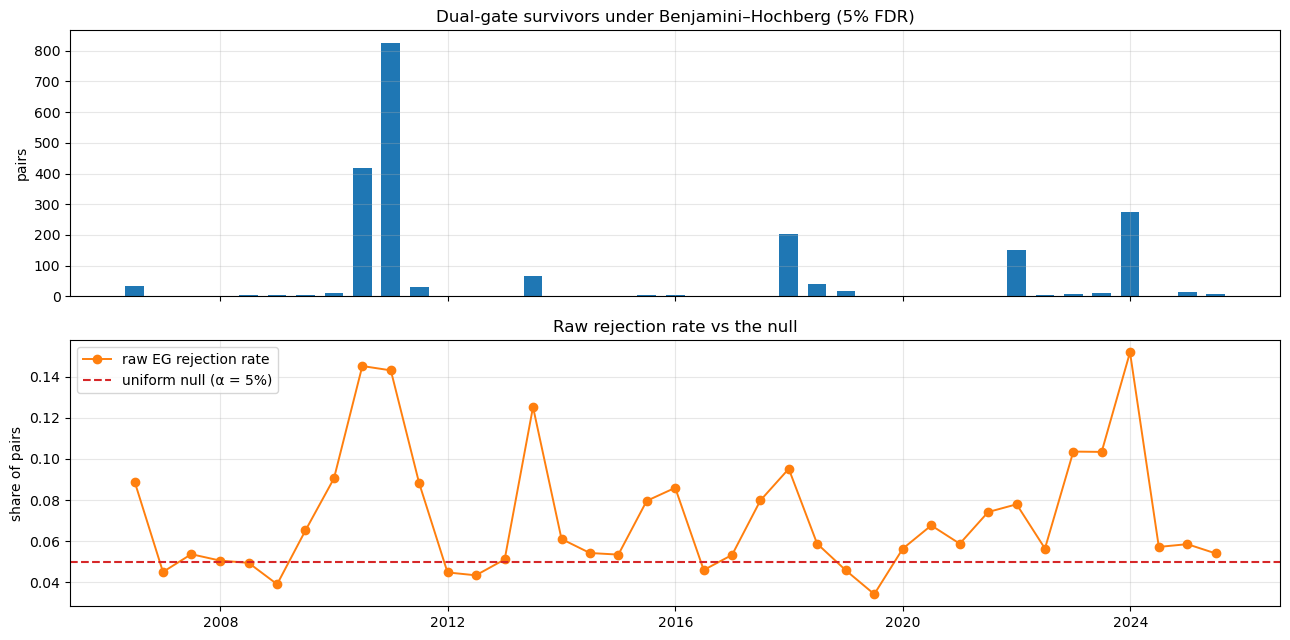

formations with no BH discovery at all: 9 of 39
BH discoveries per formation: median 3, max 825 (2010-12-31)
raw dual-gate 'discoveries' per formation: median 1,451 — the same screen without the correction


In [4]:
fig, ax = plt.subplots(2, 1, figsize=(13, 6.5), sharex=True)
ax[0].bar(per_form.index, per_form["bh_dual"], width=120, color="tab:blue")
ax[0].set_ylabel("pairs"); ax[0].set_title("Dual-gate survivors under Benjamini–Hochberg (5% FDR)")
ax[1].plot(per_form.index, per_form["raw_eg_rate"], marker="o", lw=1.4, color="tab:orange", label="raw EG rejection rate")
ax[1].axhline(ALPHA, color="tab:red", ls="--", lw=1.5, label="uniform null (α = 5%)")
ax[1].set_ylabel("share of pairs"); ax[1].set_title("Raw rejection rate vs the null"); ax[1].legend()
plt.tight_layout(); plt.show()
print(f"formations with no BH discovery at all: {int((per_form['bh_dual'] == 0).sum())} of {len(per_form)}")
print(f"BH discoveries per formation: median {int(per_form['bh_dual'].median())}, max {int(per_form['bh_dual'].max())} "
      f"({per_form['bh_dual'].idxmax().date()})")
print(f"raw dual-gate 'discoveries' per formation: median {int(per_form['raw_dual'].median()):,} — "
      f"the same screen without the correction")

Mostly it is not. The median formation yields **3** dual-gate survivors out of roughly 44,000 pairs
tested, nine of the 39 formations yield none at all, and the distribution is violently uneven: a handful
of dates — 2010-12, 2017-12, 2023-12 — produce hundreds while most of the rest produce nothing or a
handful. Those spikes line up
with periods when the whole market moved together, which is precisely when spurious common trends are
easiest to find and least likely to persist.

The lower panel is the same point in a different currency. The raw rejection rate sits above the 5% line the
null predicts in most formations and averages about 7% — but it is noisy, running from under 4% to over
9% depending on the date. Without the correction the same
screen reports a median of **1,451 "cointegrated" pairs per formation** — a number that looks like a rich
opportunity set and is very close to what pure noise would produce. Notebook 03 runs the whole pipeline
that way as an ablation; this is what it is ablating.

## 4. Does a longer formation window find more?

Cointegration tests gain power with sample length, so a two-year window may simply be too short. Against
that, the longer the window the less plausible it is that one linear relation held throughout. Running
three window lengths on the same formation dates separates the two effects.

In [5]:
f_power = CACHE / "day_screen_power.parquet"
PROBE = list(FORMATIONS[::6])
if f_power.exists():
    power = pd.read_parquet(f_power)
else:
    rows = []
    for years in (1, 2, 3):
        for d in PROBE:
            names = universe_at(d, years=years)
            w = window_bars(d, years)
            px = w["close"].unstack("ticker")[names].dropna(axis=1)
            if px.shape[1] < 50:
                continue
            long = px.stack().rename("close").to_frame(); long.index.names = ["datetime", "ticker"]
            long = long.reorder_levels(["ticker", "datetime"]).sort_index()
            sc = find_cointegrated_pairs_dualgate(long, alpha_eg=ALPHA, alpha_joh=ALPHA, fdr_method="bh", show_progress=False)
            rows.append({"years": years, "formation": d, "sessions": px.shape[0], "tickers": px.shape[1],
                         "pairs": len(sc), "bh_dual": int((sc["verdict"] == "pass").sum()),
                         "raw_eg_rate": float((sc["eg_p"] <= ALPHA).mean()),
                         "pi0": float((sc["eg_p"] > 0.5).sum() / (len(sc) * 0.5))})
    power = pd.DataFrame(rows); power.to_parquet(f_power)
display(power.pivot_table(index="formation", columns="years", values=["bh_dual", "raw_eg_rate", "pi0"]).round(3))
print(power.groupby("years")[["sessions", "bh_dual", "raw_eg_rate", "pi0"]].mean().round(3).to_string())

bh_dual                pi0               raw_eg_rate              
years            1     2     3      1      2      3           1      2      3
formation                                                                    
2006-06-30     2.0  34.0   0.0  0.969  0.906  0.846       0.041  0.089  0.088
2009-07-01   186.0   5.0   6.0  0.750  0.792  1.073       0.121  0.065  0.054
2012-06-29    32.0   1.0  49.0  0.908  1.005  0.838       0.072  0.043  0.065
2015-07-01     0.0   4.0   3.0  0.880  0.887  1.055       0.061  0.080  0.054
2018-06-29     0.0  39.0  43.0  1.010  0.972  0.875       0.060  0.059  0.102
2021-07-01     0.0   2.0   2.0  0.814  1.053  1.030       0.084  0.074  0.061
2024-07-01     1.0   2.0   9.0  1.066  0.827  0.890       0.033  0.057  0.092

       sessions  bh_dual  raw_eg_rate    pi0
years                                       
1       252.000   31.571        0.068  0.914
2       504.286   12.429        0.067  0.920
3       737.429   16.000        0.074  0.944


No: it trades one problem for another. One-year windows yield the *most* BH discoveries on average (31.6
per formation against 12.4 at two years), but their $\hat\pi_0$ is the lowest (0.91) and their rejection
rate the least stable — short windows let a shared trend masquerade as a long-run relation. Three-year
windows have the most statistical power per test and the highest $\hat\pi_0$ (0.94), meaning the extra
length mostly buys cleaner evidence that there is nothing to find. Two years is the compromise the rest
of the series uses, and nothing in this table suggests another choice would rescue the strategy.

## 5. What actually passes

The identity of the survivors matters as much as the count. A genuine statistical-arbitrage relationship
is between two different businesses whose spread is economically anchored. A pair of share classes, or
two funds tracking the same index, is cointegrated for a trivial reason and offers a spread measured in
basis points.

In [6]:
passed = screen[screen["verdict"] == "pass"].copy()
passed["pair"] = passed["ticker1"] + "/" + passed["ticker2"]
top = passed["pair"].value_counts()
print(f"{len(passed):,} BH dual-gate survivors in total, {passed['pair'].nunique():,} distinct pairs")
print("\npairs that survive most often across the 39 formations:")
display(top.head(20).rename("formations passed").to_frame())
deg = pd.concat([passed["ticker1"], passed["ticker2"]]).value_counts()
print("tickers appearing in the most surviving pairs:", deg.head(10).to_dict())
best = passed.nsmallest(15, "eg_p_fdr")[["formation", "pair", "eg_t", "eg_p_fdr", "joh_stat"]]
print("\nstrongest individual survivors:")
display(best.assign(formation=best["formation"].dt.date).round(4).to_string(index=False))

2,151 BH dual-gate survivors in total, 2,094 distinct pairs

pairs that survive most often across the 39 formations:


,formations passed
pair,
IVV/SPY,15
SPY/VOO,10
IVV/VOO,7
IJH/MDY,5
CVS/FCX,2
PX/RIMM,2
BK/LVS,2
BK/UYG,2
BK/WFT,2


tickers appearing in the most surviving pairs: {'KR': 140, 'BDX': 136, 'DUST': 103, 'UNG': 95, 'STI': 84, 'FAS': 83, 'LLY': 69, 'CHK': 64, 'NBR': 54, 'MGM': 47}

strongest individual survivors:


' formation      pair     eg_t  eg_p_fdr  joh_stat\n2018-12-31   HLT/MAR -15.4842       0.0   18.8539\n2008-07-01   IVV/SPY -12.7537       0.0  102.3995\n2010-12-31   IVV/SPY -12.2626       0.0  102.0574\n2012-12-31   IVV/SPY -11.4472       0.0  100.3878\n2025-07-01  SPLG/VOO -10.7451       0.0   83.9621\n2013-07-01   IVV/SPY -10.7053       0.0   86.3198\n2018-12-31   CAT/HLT -10.0069       0.0   19.6961\n2017-06-30   IJH/MDY  -9.9753       0.0   71.1581\n2011-12-30   IVV/SPY  -9.8659       0.0   78.7204\n2025-07-01  SPLG/SPY  -9.4892       0.0  103.4781\n2017-12-29 DUST/VIAB  -9.5548       0.0   31.9998\n2018-12-31  ANET/HLT  -9.1462       0.0   19.5896\n2025-07-01   IVV/SPY  -9.0664       0.0   84.0000\n2025-07-01   SPY/VOO  -9.0753       0.0   74.8795\n2018-12-31   HLT/SMH  -8.9000       0.0   15.7656'

The most reliable survivors are not businesses — they are the same asset twice. `IVV/SPY` passes in 15 of
39 formations, `SPY/VOO` in 10, `IVV/VOO` in 7, `IJH/MDY` in 5: pairs of ETFs tracking the identical
index, whose spread is a fee-and-tracking difference of a few basis points. They are genuinely
cointegrated and they are not a statistical-arbitrage opportunity.

Below them the list gets noisier rather than more interesting. The biggest hubs — KR and BDX with well
over a hundred pairs each, and the leveraged and commodity funds DUST, FAS and UNG — are the signature of
one series with an unusual path cointegrating against a large slice of the universe at once, not of a
hundred genuine relationships. The exception worth naming is `HLT/MAR`, Hilton against Marriott: the
strongest non-ETF result in twenty years and exactly the kind of same-industry pair the theory predicts.
Finding one clean example in 1.7 million tests is a fair summary of the evidence.

## 6. The distance method as a benchmark

Gatev et al. (2006) select pairs without any test: normalise both price series to 1 at the start of the
formation window and take the pairs with the smallest sum of squared deviations. It is the oldest and
most replicated pairs-trading rule, and it makes a useful control — if cointegration testing adds
nothing, the two selections should perform alike in notebook 09.

In [7]:
def distance_rank(end, k=20, years=FORM_YEARS):
    names = universe_at(end, years=years)
    px = window_bars(end, years)["close"].unstack("ticker")[names].dropna(axis=1)
    norm = px / px.iloc[0]
    cols = list(norm.columns); M = norm.to_numpy()
    ssd = ((M[:, :, None] - M[:, None, :]) ** 2).sum(axis=0)
    iu = np.triu_indices(len(cols), 1)
    s = pd.Series(ssd[iu], index=pd.MultiIndex.from_arrays(
        [[cols[i] for i in iu[0]], [cols[j] for j in iu[1]]], names=["ticker1", "ticker2"]))
    return s.sort_values().head(k)

f_dist = CACHE / "day_distance.parquet"
if f_dist.exists():
    distance = pd.read_parquet(f_dist)
else:
    rows = []
    for d in FORMATIONS:
        s = distance_rank(d, k=20)
        rows.append(pd.DataFrame({"formation": d, "ticker1": s.index.get_level_values(0),
                                  "ticker2": s.index.get_level_values(1), "ssd": s.to_numpy(),
                                  "rank": np.arange(1, len(s) + 1)}))
    distance = pd.concat(rows, ignore_index=True); distance.to_parquet(f_dist)
distance["pair"] = distance["ticker1"] + "/" + distance["ticker2"]
print("pairs the distance method picks most often:")
display(distance["pair"].value_counts().head(15).rename("formations in the top 20").to_frame())
key = lambda df: {(f, *sorted((a, b))) for f, a, b in zip(df["formation"], df["ticker1"], df["ticker2"])}
overlap = len(key(distance) & key(passed))
print(f"\noverlap between the distance top-20 and the BH survivors: {overlap} of {len(distance):,} "
      f"distance selections and {len(passed):,} BH survivors")

pairs the distance method picks most often:


,formations in the top 20
pair,
EEM/VWO,25
SPY/IVV,22
GOOGL/GOOG,18
EEM/IEMG,18
IYR/VNQ,15
MDY/IJH,13
IWM/IWO,12
EFA/VEA,11
SPXL/UPRO,11



overlap between the distance top-20 and the BH survivors: 43 of 780 distance selections and 2,151 BH survivors


The distance method arrives at the same place from a different direction, and more bluntly: its most
frequent picks are `EEM/VWO`, `SPY/IVV`, `GOOGL/GOOG`, `EEM/IEMG` and `IYR/VNQ` — index clones and two
share classes of the same company. It agrees with the BH screen on only 43 of 780 selections, so the two
rules are close to independent, which makes them a genuine comparison rather than a re-run.

## 7. What notebook 09 will trade

Three rules, deliberately spanning the range from strict to none:

* **`bh_dual`** — the FDR-controlled survivors. Nothing at all in nine of the thirty-nine formations; a
  median of 3 per formation across all of them, 6 across the thirty that produce anything;
  the statistically defensible candidate set, and very thin.
* **`raw_dual_top20`** — the 20 smallest raw $p$-values that also clear Johansen, with no correction.
  Always full, and on the evidence above largely noise. If cointegration testing adds value this should
  underperform the first rule; if the corrected screen is mostly finding ETF clones, it may not.
* **`distance_top20`** — the Gatev et al. selection, which performs no test at all.

Notebook 09 trades all three over the same twenty years with the same hedge, costs and universe.

In [8]:
rules = {}
rules["bh_dual"] = passed[["formation", "ticker1", "ticker2", "eg_p_fdr"]].copy()
raw = screen[(screen["eg_p"] <= ALPHA) & screen["joh_pass"]].copy()
rules["raw_dual_top20"] = (raw.sort_values(["formation", "eg_p"]).groupby("formation").head(20)
                           [["formation", "ticker1", "ticker2", "eg_p"]].copy())
rules["distance_top20"] = distance[["formation", "ticker1", "ticker2", "ssd"]].copy()
for name, df in rules.items():
    df.to_parquet(CACHE / f"day_rule_{name}.parquet")
    n = df.groupby("formation").size()
    print(f"{name:18s}: {len(df):5,} selections over {df['formation'].nunique()} formations "
          f"(median {int(n.median())} per formation, {int((n == 0).sum())} empty)")

bh_dual           : 2,151 selections over 30 formations (median 6 per formation, 0 empty)
raw_dual_top20    :   780 selections over 39 formations (median 20 per formation, 0 empty)
distance_top20    :   780 selections over 39 formations (median 20 per formation, 0 empty)
